# Data

In [ ]:
pip install geoplot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 30.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 41.4 MB/s eta 0:00:00


In [ ]:
pip install geopandas

In [ ]:
import pandas as pd
from altair import Chart, X, Y, Color, Scale
import altair as alt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import datetime
import geoplot as gplt
import geopandas as gpd
import folium

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ny2 = pd.read_csv('/content/drive/MyDrive/Career/Colab Notebooks/County_Mental_Health_Profiles__2006-2016.csv').dropna(axis=1, how='all')
ny2.tail(5)

,Row Created Date Time,Service Year,OMH Region Code,OMH Region Label,County Label,Age Group,Rate Code Group,Recipient Count By County,Count Of Recipients By Rate Code Group And County,Units Total,Paid Claim Total
7660,2018-04-27T10:06:00.000,2006,5,Long Island,Suffolk,CHILD,Home and Community Based Services Waiver (HCBS),2665,87,534.0,1363570
7661,2018-04-27T10:06:00.000,2006,5,Long Island,Suffolk,CHILD,Partial Hospitalization,2665,92,1655.0,219067
7662,2018-04-27T10:06:00.000,2006,5,Long Island,Suffolk,CHILD,Psychiatric Inpatient,2665,524,28951.0,18485207
7663,2018-04-27T10:06:00.000,2006,5,Long Island,Suffolk,CHILD,Psychiatric Inpatient OMH,2665,198,15321.0,15987864
7664,2018-04-27T10:06:00.000,2006,5,Long Island,Suffolk,CHILD,"Targeted Case Management (ICM, BCM, SCM)",2665,216,1443.0,640592


# About the Data:

Retreived from https://catalog.data.gov/dataset/county-mental-health-profiles-2006-2016

These reports provide summary information about mental health service utilization funded through Medicaid for Local Fiscal Years, beginning in service year 2006 and updated yearly thereafter. Totals are based on date of service and data are refreshed on a monthly basis so values in the same report may change over time. Prepaid Mental Health Plan (PMHP) data are included in these reports as Recovery Services (RS); however, Medicaid Managed Care data are not included. Expenditures include Comprehensive Outpatient Program Services (COPS) and Community Support Program (CSP) add-on payments, where applicable.

It was published by the state of New York and intended for public use.

## Codebook




*   Row Created Date Time: date and time inquiry inputed

*   Service Year: the year care service was performed

*   OMH Region Code: Office of Mental Health region numerical code

*   OMH Region Label: Office of Mental Health region label

*   County Label: county name

*   Age Group: the age group of the individual who received care service

*   Rate Code Group: the type of care service provided

*   Recipient Count by County: total of individuals who who received care services in specific county

*   Count Of Recipients By Rate Code Group And County: total of individuals who who received specific care service by individual county

*   Units Total: Total amount of recipients

*   Paid Claim Total: Total amount of outreach services paid through program






# Cleaning the Data

We will now begin cleaning the data to make them easily malleable for our purposes.

Cleaning this data will include renaming columns by inplacing underscores (_) so that they are easily callable when writing code

In [ ]:
ny2.rename(columns = {'Age Group':'Age'}, inplace = True)
ny2.rename(columns = {'Service Year':'service_year'}, inplace = True)
ny2.rename(columns = {'OMH Region Code':'OMH_Region_Code'}, inplace = True)
ny2.rename(columns = {'County Label':'County_Label'}, inplace = True)
ny2.rename(columns = {'Rate Code Group':'Rate_Code_Group'}, inplace = True)
ny2.rename(columns = {'Recipient Count By County':'Recipient_Count_By_County'}, inplace = True)
ny2.rename(columns = {'Count Of Recipients By Rate Code Group And County':'County_Of_Recipients_By_Rate_Code_Group_And_County'}, inplace = True)
ny2.rename(columns = {'Units Total':'Units_Total'}, inplace = True)
ny2.rename(columns = {'Paid Claim Total':'Paid_Claim_Total'}, inplace = True)
ny2.head()

,Row Created Date Time,service_year,OMH_Region_Code,OMH Region Label,County_Label,Age,Rate_Code_Group,Recipient_Count_By_County,Count Of Recipients By Rate Code Group And County,Units_Total,Paid_Claim_Total
0,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Clinic Treatment,435,323,3023.0,301130
1,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Community Residence,435,18,141.0,326026
2,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Health Home,435,37,168.0,79744
3,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Personalized Recovery Oriented Services,435,118,1080.0,462192
4,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,"Targeted Case Management (ICM, BCM, SCM)",435,1,3.0,1776


We will now group the data by county as
our analysis compares statistics between
counties. By doing this we can see the distribution of resources across the state

In [ ]:
amount_per_county=ny2.groupby(by=['County_Label'])

In [ ]:
amount_per_county.head()

,Row Created Date Time,service_year,OMH_Region_Code,OMH Region Label,County_Label,Age,Rate_Code_Group,Recipient_Count_By_County,Count Of Recipients By Rate Code Group And County,Units_Total,Paid_Claim_Total
0,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Clinic Treatment,435,323,3023.0,301130
1,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Community Residence,435,18,141.0,326026
2,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Health Home,435,37,168.0,79744
3,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,Personalized Recovery Oriented Services,435,118,1080.0,462192
4,2018-04-27T10:06:00.000,2016,1,Western NY,Allegany,ADULT,"Targeted Case Management (ICM, BCM, SCM)",435,1,3.0,1776
...,...,...,...,...,...,...,...,...,...,...,...
5843,2018-04-27T10:06:00.000,2008,2,Central NY,Hamilton,ADULT,Clinic Treatment,346,341,1237.0,27218
5844,2018-04-27T10:06:00.000,2008,2,Central NY,Hamilton,ADULT,"Targeted Case Management (ICM, BCM, SCM)",346,11,61.0,35357
5845,2018-04-27T10:06:00.000,2008,2,Central NY,Hamilton,CHILD,Clinic Treatment,21,21,63.0,992
6540,2018-04-27T10:06:00.000,2007,2,Central NY,Hamilton,ADULT,Clinic Treatment,20,4,6.0,172


The mental health dataset we used has a county that does not match with the JSON files we use in the chloropeth map in one of our questions.  We needed to match the county names prior to downloading geopandas, so we'll do that here as we continue to clean the dataset and make it workable.

In [ ]:
ny2['County_Label'] = ny2['County_Label'].replace(['Saint Lawrence'],'St. Lawrence')
ny2.County_Label.unique()

array(['Allegany', 'Cattaraugus', 'Chautauqua', 'Chemung', 'Erie',
       'Genesee', 'Livingston', 'Monroe', 'Niagara', 'Ontario', 'Orleans',
       'Schuyler', 'Seneca', 'Steuben', 'Tioga', 'Tompkins', 'Wayne',
       'Wyoming', 'Yates', 'Broome', 'Cayuga', 'Chenango', 'Clinton',
       'Cortland', 'Delaware', 'Essex', 'Franklin', 'Fulton', 'Herkimer',
       'Jefferson', 'Lewis', 'Madison', 'Montgomery', 'Oneida',
       'Onondaga', 'Oswego', 'Otsego', 'St. Lawrence', 'Albany',
       'Columbia', 'Dutchess', 'Greene', 'Orange', 'Putnam', 'Rensselaer',
       'Rockland', 'Saratoga', 'Schenectady', 'Schoharie', 'Sullivan',
       'Ulster', 'Warren', 'Washington', 'Westchester', 'Bronx', 'Kings',
       'New York', 'Queens', 'Richmond', 'Nassau', 'Suffolk', 'Hamilton'],
      dtype=object)

Now we are going to get some exploratoring to learn more about the data and see if there are any further steps we need to do in cleaning

In [ ]:
ny2.describe()

,service_year,OMH_Region_Code,Recipient_Count_By_County,Count Of Recipients By Rate Code Group And County,Units_Total,Paid_Claim_Total
count,7665.000000,7665.000000,7665.000000,7665.000000,7665.000000,7.665000e+03
mean,2011.015264,2.461709,4561.181344,571.947815,9503.758784,3.362106e+06
std,3.169721,1.188246,7598.725999,1986.485083,33018.846081,1.008736e+07
min,2006.000000,1.000000,1.000000,1.000000,-154.000000,-3.412820e+05
25%,2008.000000,1.000000,584.000000,37.000000,299.000000,2.046350e+05
50%,2011.000000,2.000000,1437.000000,115.000000,1615.000000,7.231780e+05
75%,2014.000000,3.000000,4544.000000,391.000000,6076.000000,2.490122e+06
max,2016.000000,5.000000,42088.000000,30244.000000,532911.000000,1.989332e+08


In [ ]:
ny2.shape

(7665, 11)

In [ ]:
ny2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7665 entries, 0 to 7664
Data columns (total 11 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Row Created Date Time                               7665 non-null   object 
 1   service_year                                        7665 non-null   int64  
 2   OMH_Region_Code                                     7665 non-null   int64  
 3   OMH Region Label                                    7665 non-null   object 
 4   County_Label                                        7665 non-null   object 
 5   Age                                                 7665 non-null   object 
 6   Rate_Code_Group                                     7665 non-null   object 
 7   Recipient_Count_By_County                           7665 non-null   int64  
 8   Count Of  Recipients By Rate Code Group And County  7665 non-null   int64  
 9

# Q-1: What percentage of total expenditures is used in each county?

Setting up data percentages

Mapping

In [ ]:
# Load the json file with county coordinates
geoData = gpd.read_file('https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/US-counties.geojson')

# Make sure the "id" column is an integer
geoData.id = geoData.id.astype(str).astype(int)

# Remove all states & territories but NY
stateToRemove = ['01','02','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','21','22','23','24','25','26','27','28','29',
                 '30','31','32','33', '34','35', '37','38', '39', '40', '41','42','43','44','45','46','47','48','49','50', '51', '52', '53', '54', '55', '56', '57', '58', '72']
geoData = geoData[~geoData.STATE.isin(stateToRemove)]

In [ ]:
m = folium.Map(location=[42.651725769, -73.755096436], zoom_start=7)

byCounty = ny2[['County_Label', 'Paid_Claim_Total']]

byCounty = byCounty.groupby(['County_Label'])['Paid_Claim_Total'].agg('sum').reset_index()
byCounty

,County_Label,Paid_Claim_Total
0,Albany,678072538
1,Allegany,22201628
2,Bronx,2385336066
3,Broome,325396132
4,Cattaraugus,91216166
...,...,...
57,Washington,24619470
58,Wayne,56346715
59,Westchester,1807564295
60,Wyoming,25759741


In [ ]:
percentageByCounty = (byCounty.Paid_Claim_Total / byCounty.Paid_Claim_Total.sum()*100)
percentageByCounty

0     2.631192
1     0.086151
2     9.256056
3     1.262667
4     0.353955
        ...   
57    0.095533
58    0.218648
59    7.014071
60    0.099958
61    0.077429
Name: Paid_Claim_Total, Length: 62, dtype: float64

In [ ]:
byCounty['percentageByCounty']= percentageByCounty
byCounty

,County_Label,Paid_Claim_Total,percentageByCounty
0,Albany,678072538,2.631192
1,Allegany,22201628,0.086151
2,Bronx,2385336066,9.256056
3,Broome,325396132,1.262667
4,Cattaraugus,91216166,0.353955
...,...,...,...
57,Washington,24619470,0.095533
58,Wayne,56346715,0.218648
59,Westchester,1807564295,7.014071
60,Wyoming,25759741,0.099958


In [ ]:
folium.Choropleth(

    geo_data=geoData,
    data=byCounty,
    columns=["County_Label", "percentageByCounty"],
    key_on="feature.properties.NAME",
    fill_color="BuPu",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Percentage Paid Claims By County)",
    #bins=bins,
    reset=True,
).add_to(m)
m

## Discussion:

Looking at the distribution of total expenditures by counties helps us determine if there are any outliers in the distribution of funds or if it remains equal between countires. By the map above, we can see the relative percent of of total paid claims. For the majority of the counties, we can see they stay mainly under 2% of expenditure. The outliers lie around the coast where the cities with higher population are. This seems to be a fair distribution of funds per county with their respective populations.

# Q-2: What are the top 5 counties with the highest paid total claims payout in 2012?

In [ ]:
pt2 = pd.pivot_table(byCounty, index = 'County_Label', values = 'Paid_Claim_Total')
pt2.head()

,Paid_Claim_Total
County_Label,
Albany,678072538
Allegany,22201628
Bronx,2385336066
Broome,325396132
Cattaraugus,91216166


In [ ]:
pt2.sort_values('Paid_Claim_Total').tail()

,Paid_Claim_Total
County_Label,
Suffolk,1816671690
Bronx,2385336066
Queens,2778870552
Kings,3136785612
New York,3548105133


## Discussion:

By finding the top 5 highest counties we can confirm these counties as the highest populations and that they recieve the most funding because of that. This is beneficial to keep for reference as we run further analysis on more aspects of this data and depending on what we are looking at, it may be beneificial to check these counties as among the higher fund receivers and spenders.

# Q-3: What is the change of overall expenditure for services from 2006-2016 in New York

In [ ]:
total_per_year = ny2[['service_year', 'Paid_Claim_Total']]

In [ ]:
total_per_year = total_per_year.groupby(['service_year'])['Paid_Claim_Total'].agg('sum').reset_index()
total_per_year['percentage'] = (total_per_year.Paid_Claim_Total / total_per_year.Paid_Claim_Total.sum())*100
total_per_year

,service_year,Paid_Claim_Total,percentage
0,2006,2426719085,9.416639
1,2007,2457939592,9.537787
2,2008,2575336266,9.993333
3,2009,2632475586,10.215056
4,2010,2648064441,10.275547
5,2011,2539340233,9.853654
6,2012,2369901637,9.196165
7,2013,2208489703,8.569822
8,2014,2106141649,8.172671
9,2015,2088576705,8.104512


In [ ]:
total_per_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   service_year      11 non-null     int64  
 1   Paid_Claim_Total  11 non-null     int64  
 2   percentage        11 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 392.0 bytes


Here we can see service_year is not assigned a date/time type. Due to this, we have to take steps to correct this for proper plotting to occur.

In [ ]:
total_per_year['service_year'] = total_per_year['service_year'].apply(lambda m: pd.to_datetime(str(m), format='%Y'))
total_per_year

,service_year,Paid_Claim_Total,percentage
0,2006-01-01,2426719085,9.416639
1,2007-01-01,2457939592,9.537787
2,2008-01-01,2575336266,9.993333
3,2009-01-01,2632475586,10.215056
4,2010-01-01,2648064441,10.275547
5,2011-01-01,2539340233,9.853654
6,2012-01-01,2369901637,9.196165
7,2013-01-01,2208489703,8.569822
8,2014-01-01,2106141649,8.172671
9,2015-01-01,2088576705,8.104512


In [ ]:
total_per_year.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   service_year      11 non-null     datetime64[ns]
 1   Paid_Claim_Total  11 non-null     int64         
 2   percentage        11 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 392.0 bytes


In [ ]:
alt.Chart(total_per_year).mark_area(
    line={'color':'darkgreen'},
    color=alt.Gradient(
        gradient='linear',
        stops=[alt.GradientStop(color='white', offset=0),
               alt.GradientStop(color='darkgreen', offset=1)],
        x1=1,
        x2=1,
        y1=1,
        y2=0
    )
).encode(
    alt.X('service_year:T'),
    alt.Y('Paid_Claim_Total:Q')
)

alt.Chart(...)

## Discussion:

The area chart with gradient above shows the rise and decline of total expenditures of services from 2006 to 2016. We see that it peaked shortly after the start of this data, but has been in decline for over half the data until the end in 2016. This is important to note that overall expenditure has gone down which is important to note as we are assessing this data and distribution of medicaid resources that for mental health services in New York, the overall expenses have gone down.  

# Q-4: Does the outreach to children vs adults for services differ drastically?

In [ ]:
county_age = ny2[['County_Label', 'Age']]
county_age=county_age.groupby(['County_Label','Age']).size().reset_index()

In [ ]:
adult=county_age[county_age['Age']=='ADULT']
child=county_age[county_age['Age']=='CHILD']

In [ ]:
child

,County_Label,Age,0
1,Albany,CHILD,87
3,Allegany,CHILD,30
5,Bronx,CHILD,113
7,Broome,CHILD,94
9,Cattaraugus,CHILD,48
...,...,...,...
124,Washington,CHILD,35
126,Wayne,CHILD,40
128,Westchester,CHILD,107
130,Wyoming,CHILD,24


In [ ]:
# need to rename epxenditure column
child.columns = ['County_Label', 'Age_Group', 'Expenditure']
child

,County_Label,Age_Group,Expenditure
1,Albany,CHILD,87
3,Allegany,CHILD,30
5,Bronx,CHILD,113
7,Broome,CHILD,94
9,Cattaraugus,CHILD,48
...,...,...,...
124,Washington,CHILD,35
126,Wayne,CHILD,40
128,Westchester,CHILD,107
130,Wyoming,CHILD,24


In [ ]:
adult

,County_Label,Age_Group,Expenditure
0,Albany,ADULT,101
2,Allegany,ADULT,47
4,Bronx,ADULT,126
6,Broome,ADULT,104
8,Cattaraugus,ADULT,66
...,...,...,...
123,Washington,ADULT,37
125,Wayne,ADULT,55
127,Westchester,ADULT,101
129,Wyoming,ADULT,54


In [ ]:
# need to rename epxenditure column
adult.columns = ['County_Label', 'Age_Group', 'Expenditure']
adult

,County_Label,Age_Group,Expenditure
0,Albany,ADULT,101
2,Allegany,ADULT,47
4,Bronx,ADULT,126
6,Broome,ADULT,104
8,Cattaraugus,ADULT,66
...,...,...,...
123,Washington,ADULT,37
125,Wayne,ADULT,55
127,Westchester,ADULT,101
129,Wyoming,ADULT,54


In [ ]:
mdf = pd.merge(adult, child, on='County_Label', suffixes=['_Adult','_Child'])
mdf

,County_Label,Age_Group_Adult,Expenditure_Adult,Age_Group_Child,Expenditure_Child
0,Albany,ADULT,101,CHILD,87
1,Allegany,ADULT,47,CHILD,30
2,Bronx,ADULT,126,CHILD,113
3,Broome,ADULT,104,CHILD,94
4,Cattaraugus,ADULT,66,CHILD,48
...,...,...,...,...,...
57,Washington,ADULT,37,CHILD,35
58,Wayne,ADULT,55,CHILD,40
59,Westchester,ADULT,101,CHILD,107
60,Wyoming,ADULT,54,CHILD,24


In [ ]:
da =mdf.drop(['Age_Group_Adult'],  axis = 1)
dmdf = da.drop(['Age_Group_Child'], axis = 1)
dmdf

,County_Label,Expenditure_Adult,Expenditure_Child
0,Albany,101,87
1,Allegany,47,30
2,Bronx,126,113
3,Broome,104,94
4,Cattaraugus,66,48
...,...,...,...
57,Washington,37,35
58,Wayne,55,40
59,Westchester,101,107
60,Wyoming,54,24


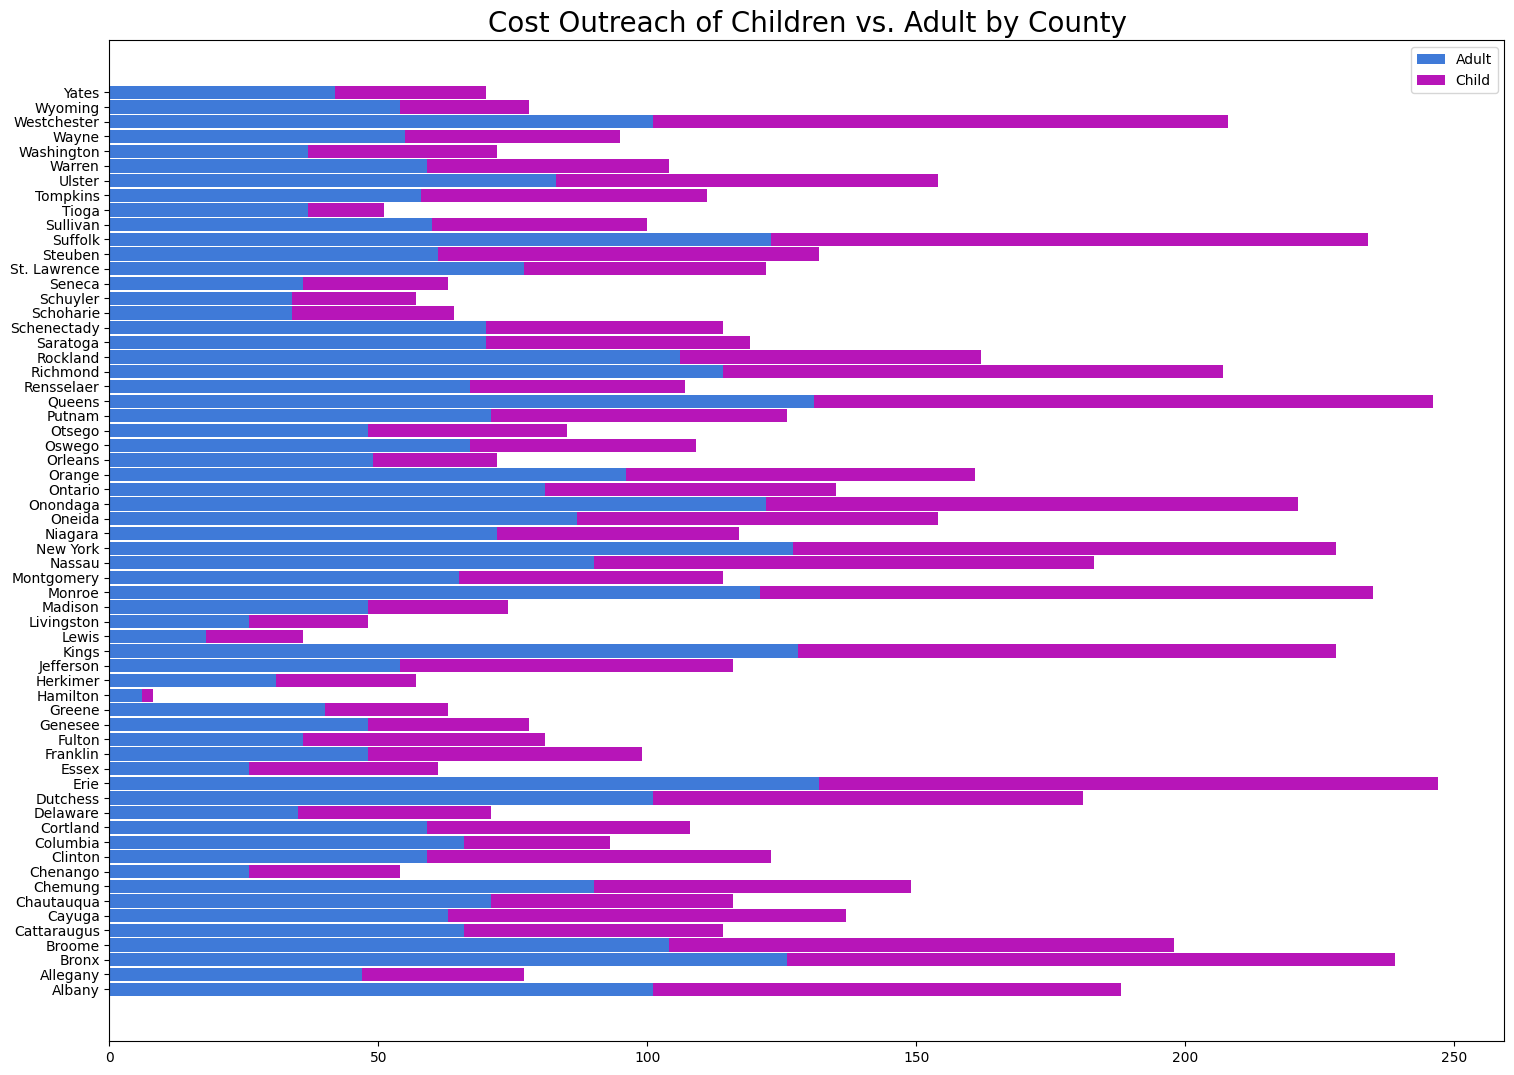

In [ ]:
datasets = {
    'Adult' : dmdf['Expenditure_Adult'],
    'Child' : dmdf['Expenditure_Child']
}
county_labels = mdf['County_Label']

bar_height = 0.9
colors = {'Adult' : '#3f7ad8', 'Child' : '#b715b8'}
insert_location = np.zeros(len(county_labels))

fig, ax = plt.subplots(figsize=(18,13))
#ax.axis.set

for label, data_points, in datasets.items():
  chart = ax.barh(county_labels, data_points, height=bar_height, color=colors[label], label=label, left=insert_location)
  #ax.bar_
  insert_location += data_points

ax.legend(loc ='upper right')
plt.title('Cost Outreach of Children vs. Adult by County', fontsize=20)
plt.show()


## Discussion:







This graph shows us the comparison between the amount of adults and children. This is a relevant comparison so we can see where the most outreach is occuring by age group. The graphs tells us that in some counties, children are receiving half of the services care, and more often more so than the adults.

# Q-5: How do the different treatments compare in cost?

In [ ]:
code_group_paid = ny2[['Rate_Code_Group', 'Paid_Claim_Total']]
code_group_paid=code_group_paid.groupby(['Rate_Code_Group']).sum().reset_index()

In [ ]:
code_group_paid['percentage'] = (code_group_paid.Paid_Claim_Total / code_group_paid.Paid_Claim_Total.sum())*100


In [ ]:
code_group_paid

,Rate_Code_Group,Paid_Claim_Total,percentage
0,Assertive Community Treatment,626222782,2.429994
1,Clinic Treatment,4850825809,18.823141
2,Community Residence,2618318846,10.160123
3,Comprehensive Psychiatric Emergency Program,139675933,0.541998
4,Continuing Day Treatment,911255615,3.536036
5,Day Treatment,562255965,2.181778
6,Family Based Treatment/Teaching Family Home,109843514,0.426237
7,Health Home,245949387,0.954382
8,Home and Community Based Services Waiver (HCBS),516501378,2.004232
9,Intensive Psychiatric Rehabilitation Treatment,69051771,0.267948


## Discussion:

This chart helps us compare the costs of the different treament groups. We can see that 12 and 1 are the top two most expensive treatments. 12 is psychiatric inpatient and 1 is clinic treatment as we see from the index on the chart. This gives us a better understanding of the costs of treatment and where the funds specifically are going to.

# Q-6: What counties had the most paid claims in 2010?




In [ ]:
claims_2010 = ny2[ny2["service_year"] == 2010]
claims_2010

,Row Created Date Time,service_year,OMH_Region_Code,OMH Region Label,County_Label,Age,Rate_Code_Group,Recipient_Count_By_County,Count Of Recipients By Rate Code Group And County,Units_Total,Paid_Claim_Total
4203,2018-04-27T10:06:00.000,2010,1,Western NY,Allegany,ADULT,Clinic Treatment,665,578,5237.0,718490
4204,2018-04-27T10:06:00.000,2010,1,Western NY,Allegany,ADULT,Continuing Day Treatment,665,134,7548.0,591909
4205,2018-04-27T10:06:00.000,2010,1,Western NY,Allegany,ADULT,"Targeted Case Management (ICM, BCM, SCM)",665,57,295.0,131747
4206,2018-04-27T10:06:00.000,2010,1,Western NY,Allegany,CHILD,Clinic Treatment,265,254,2771.0,311065
4207,2018-04-27T10:06:00.000,2010,1,Western NY,Allegany,CHILD,"Targeted Case Management (ICM, BCM, SCM)",265,58,381.0,192525
...,...,...,...,...,...,...,...,...,...,...,...
4873,2018-04-27T10:06:00.000,2010,5,Long Island,Suffolk,CHILD,Home and Community Based Services Waiver (HCBS),2721,160,9784.0,3493346
4874,2018-04-27T10:06:00.000,2010,5,Long Island,Suffolk,CHILD,Partial Hospitalization,2721,107,1775.0,258008
4875,2018-04-27T10:06:00.000,2010,5,Long Island,Suffolk,CHILD,Psychiatric Inpatient,2721,521,26734.0,20363114
4876,2018-04-27T10:06:00.000,2010,5,Long Island,Suffolk,CHILD,Psychiatric Inpatient OMH,2721,175,16671.0,20669366


In [ ]:
Chart(claims_2010).mark_bar().encode(x='County_Label', y='Paid_Claim_Total', tooltip='Recipient_Count_By_County')

alt.Chart(...)

## Discussion:

Here we isolate one year and look at the distribution of paid claims per county. This confirms the chloropleth maps distribution that more money is spent on claims in counties where the largest cities reside.

# Q-7: What is the distribution of use of psychiatric inpatient as treatment by county?

In [ ]:
inpatient1 = ny2[ny2["Rate_Code_Group"] == 'Psychiatric Inpatient OMH']
inpatient = inpatient1.copy()
inpatient

,Row Created Date Time,service_year,OMH_Region_Code,OMH Region Label,County_Label,Age,Rate_Code_Group,Recipient_Count_By_County,Count Of Recipients By Rate Code Group And County,Units_Total,Paid_Claim_Total
36,2018-04-27T10:06:00.000,2016,1,Western NY,Chemung,ADULT,Psychiatric Inpatient OMH,1832,24,3340.0,4172442
40,2018-04-27T10:06:00.000,2016,1,Western NY,Chemung,CHILD,Psychiatric Inpatient OMH,677,143,4269.0,6693943
52,2018-04-27T10:06:00.000,2016,1,Western NY,Erie,ADULT,Psychiatric Inpatient OMH,10959,62,14163.0,17374689
62,2018-04-27T10:06:00.000,2016,1,Western NY,Erie,CHILD,Psychiatric Inpatient OMH,5549,189,11775.0,19152182
86,2018-04-27T10:06:00.000,2016,1,Western NY,Monroe,ADULT,Psychiatric Inpatient OMH,10855,27,7693.0,9470936
...,...,...,...,...,...,...,...,...,...,...,...
7606,2018-04-27T10:06:00.000,2006,4,New York City,Queens,CHILD,Psychiatric Inpatient OMH,7727,161,22049.0,22737301
7616,2018-04-27T10:06:00.000,2006,4,New York City,Richmond,ADULT,Psychiatric Inpatient OMH,6341,36,5106.0,3218021
7626,2018-04-27T10:06:00.000,2006,4,New York City,Richmond,CHILD,Psychiatric Inpatient OMH,1562,40,2336.0,2413343
7652,2018-04-27T10:06:00.000,2006,5,Long Island,Suffolk,ADULT,Psychiatric Inpatient OMH,8341,82,21680.0,13929651


Chart

In [ ]:
Chart(inpatient).mark_bar().encode(x='County_Label', y='Recipient_Count_By_County', tooltip='Rate_Code_Group')

alt.Chart(...)

## Discussion:

Here, we are looking specifically at the distribution of psychiatric inpatient treatment across the counties. This is the most expensive treatment group, so to gain a better idea of distribution among counties and see if it is overly used. Again, the chart above confirms the higher use of the treatment in counties with larger populations and those of lower population seem to remain within the same range of this use of this service. This tells us that there is not a county where the most expensive treatment is being used excessively where it might create an influx in aid distribution.